<h1 align="center"> 🧬 Healthcare Premium Prediction — Impact of Genetic Risk Feature</h1>

## Objective

To evaluate whether introducing an additional feature (`genetic_risk`) improves model performance.

This experiment aims to test whether model limitations observed earlier were due to insufficient feature representation.

## Background

Previous models showed:

- Similar performance across different algorithms
- Persistent prediction errors
- No clear patterns in residual analysis

This suggested that model performance was limited by the available features.

## Hypothesis

Adding a new feature (`genetic_risk`) may help capture additional variability 
and improve prediction accuracy.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.linear_model import LinearRegression,Lasso,Ridge
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split,cross_val_score,GridSearchCV,RandomizedSearchCV
from sklearn.preprocessing import MinMaxScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from xgboost import XGBRegressor
from joblib import dump
import math

## Dataset Loading

In [2]:
df=pd.read_excel("C:/Users/elzab/Documents/Job/Data Science Learn/project_Healthcare Premium/project_1_datacleaning_&_EDA_resources/premiums_young_with_gr.xlsx")
df.head()

,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount,Genetical_Risk
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365,4
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,No Disease,Silver,11050,3
2,21,Female,Southeast,Unmarried,0,Normal,Regular,Salaried,> 40L,97,No Disease,Silver,11857,4
3,25,Male,Southeast,Unmarried,0,Normal,No Smoking,Freelancer,10L - 25L,15,No Disease,Bronze,5684,2
4,20,Male,Southeast,Unmarried,2,Overweight,No Smoking,Freelancer,10L - 25L,14,No Disease,Bronze,5712,1


### New Feature: Genetic Risk

The `genetic_risk` feature represents inherited health risk factors.

This feature is expected to:
- Improve risk representation
- Capture variability not explained by existing features

In [3]:
df.shape

(20096, 14)

In [4]:
df.columns

Index(['Age', 'Gender', 'Region', 'Marital_status', 'Number Of Dependants',
       'BMI_Category', 'Smoking_Status', 'Employment_Status', 'Income_Level',
       'Income_Lakhs', 'Medical History', 'Insurance_Plan',
       'Annual_Premium_Amount', 'Genetical_Risk'],
      dtype='object')

In [5]:
df.columns=df.columns.str.replace(" ","_").str.lower()

In [6]:
df.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365,4
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,No Disease,Silver,11050,3
2,21,Female,Southeast,Unmarried,0,Normal,Regular,Salaried,> 40L,97,No Disease,Silver,11857,4
3,25,Male,Southeast,Unmarried,0,Normal,No Smoking,Freelancer,10L - 25L,15,No Disease,Bronze,5684,2
4,20,Male,Southeast,Unmarried,2,Overweight,No Smoking,Freelancer,10L - 25L,14,No Disease,Bronze,5712,1


<h2 align="center">🧹 Data Cleaning</h3>

- Same preprocessing steps applied as previous models
- Ensures consistency for fair comparison

### 1.Handling NA Values

In [7]:
df.isna().sum()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           2
employment_status        1
income_level             4
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
genetical_risk           0
dtype: int64

if we consider the overall size of the dataset, these na values arent many. So the best thing to do is discard those rows. 

In [8]:
df.dropna(inplace=True)
df.isna().sum()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           0
employment_status        0
income_level             0
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
genetical_risk           0
dtype: int64

### 2. Duplicate Records

In [9]:
df.duplicated().sum()

0

In [10]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

0

### 3. Invalid Values

In [11]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount,genetical_risk
count,20090.000000,20090.000000,20090.000000,20090.000000,20090.000000
mean,21.494375,0.718019,22.510851,8142.096267,2.503932
std,2.294052,0.940713,23.420493,2749.906347,1.710203
min,18.000000,-3.000000,1.000000,3501.000000,0.000000
25%,19.000000,0.000000,6.000000,6022.250000,1.000000
50%,22.000000,0.000000,16.000000,7939.000000,3.000000
75%,23.000000,1.000000,31.000000,9561.000000,4.000000
max,25.000000,3.000000,790.000000,18186.000000,5.000000


In [12]:
df[df.number_of_dependants<0].shape

(22, 14)

In [13]:
df[df.number_of_dependants<0]["number_of_dependants"].unique()

array([-3, -1], dtype=int64)

This would have occured probably because there was a bug in the data collection script. Instead of 1 and 3, it would have been saved -1 and -3.

In [14]:
df["number_of_dependants"]=abs(df["number_of_dependants"])
df["number_of_dependants"].describe()

count    20090.000000
mean         0.722598
std          0.937200
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          3.000000
Name: number_of_dependants, dtype: float64

In [15]:
numeric_columns=df.select_dtypes(["float64","int64"]).columns
numeric_columns

Index(['age', 'number_of_dependants', 'income_lakhs', 'annual_premium_amount',
       'genetical_risk'],
      dtype='object')

### 📊 Outlier Treatment

##### age

In [16]:
df[df.age>100]

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk


In [17]:
df1=df[df.age<=100].copy()
df1.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount,genetical_risk
count,20090.000000,20090.000000,20090.000000,20090.000000,20090.000000
mean,21.494375,0.722598,22.510851,8142.096267,2.503932
std,2.294052,0.937200,23.420493,2749.906347,1.710203
min,18.000000,0.000000,1.000000,3501.000000,0.000000
25%,19.000000,0.000000,6.000000,6022.250000,1.000000
50%,22.000000,0.000000,16.000000,7939.000000,3.000000
75%,23.000000,1.000000,31.000000,9561.000000,4.000000
max,25.000000,3.000000,790.000000,18186.000000,5.000000


##### Income

In [18]:
quantile_threshold=df1.income_lakhs.quantile(0.999)
quantile_threshold

100.0

In [19]:
df1[df1.income_lakhs>quantile_threshold].shape

(4, 14)

In [20]:
df2=df1[df1.income_lakhs<=quantile_threshold].copy()

In [21]:
df2.shape

(20086, 14)

### Numeric Columns Analysis

#### Univariate Analysis

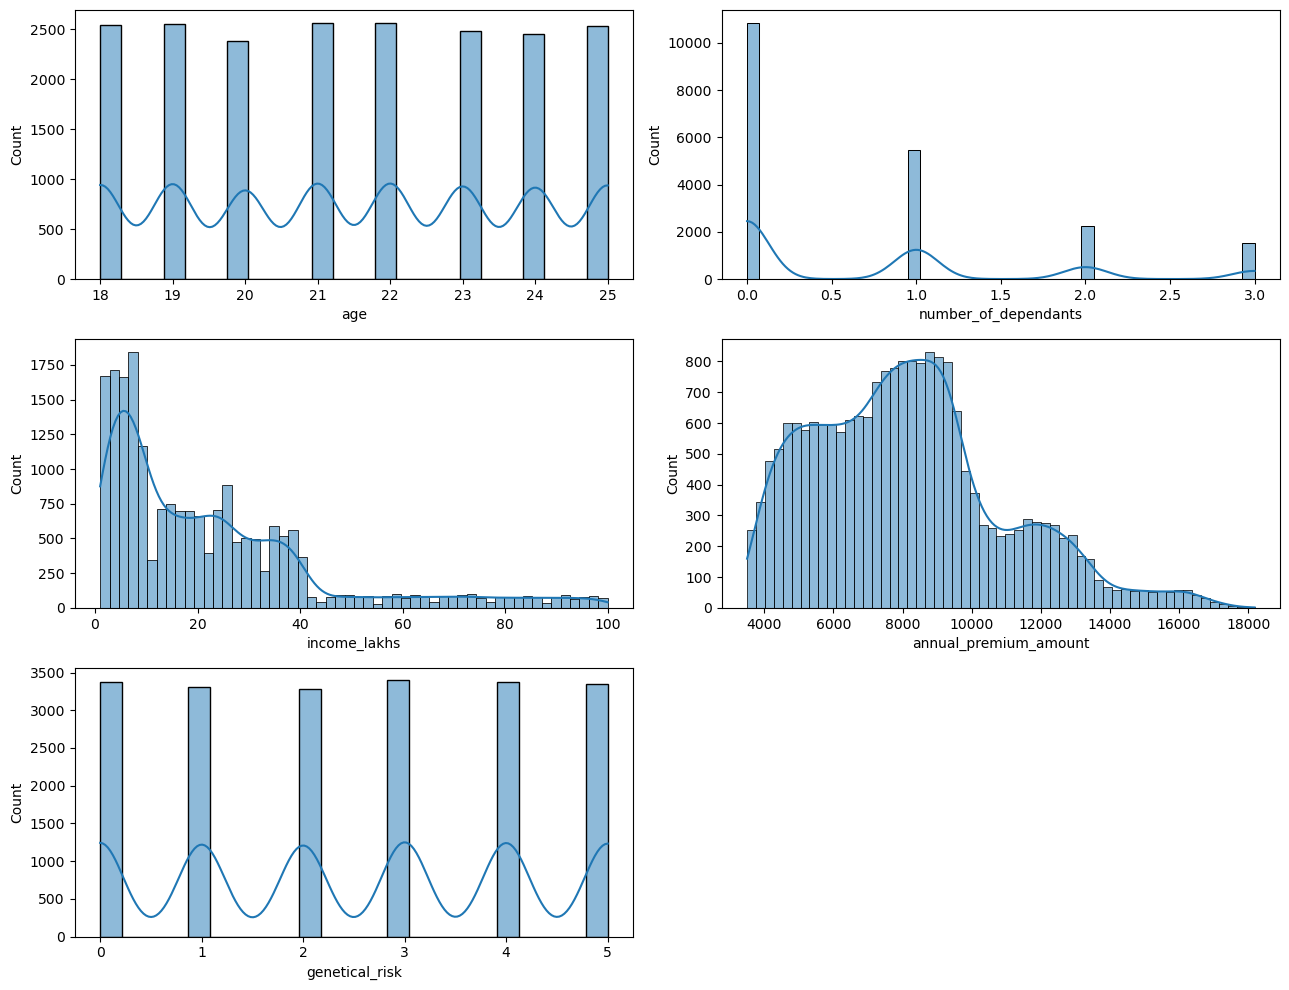

In [22]:
plt.figure(figsize=(13,10))
n_cols=2
n_rows=math.ceil(len(numeric_columns)/n_cols)
for i,col in enumerate(numeric_columns):
    plt.subplot(n_rows,n_cols,i+1)
    sns.histplot(x=df2[col],kde=True)
plt.tight_layout()
plt.show()

#### Bivariate Analysis:Numeric Columns

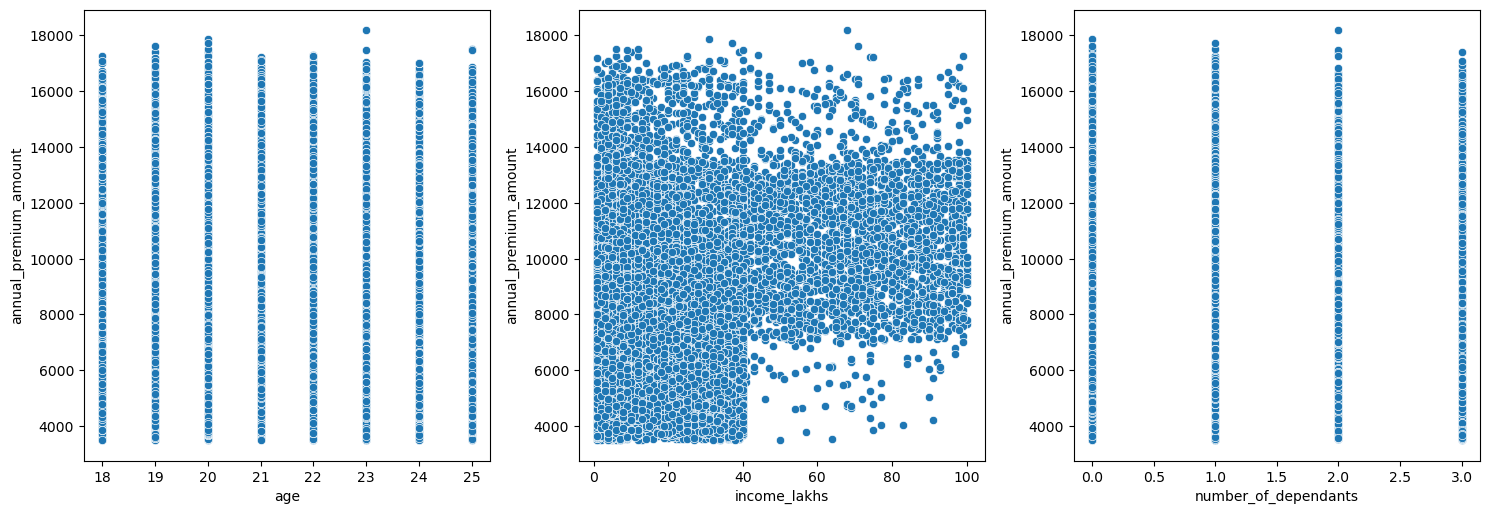

In [23]:
plt.figure(figsize=(15,15))
features = ["age", "income_lakhs", "number_of_dependants"]
for i,col in enumerate(features):
    plt.subplot(3,3,i+1)
    sns.scatterplot(df2,x=col,y="annual_premium_amount")
plt.tight_layout()
plt.show()

### Categorical Columns Analysis

In [24]:
categorical_col=df.select_dtypes(include=["object","category"]).columns
categorical_col

Index(['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status',
       'employment_status', 'income_level', 'medical_history',
       'insurance_plan'],
      dtype='object')

In [25]:
for col in categorical_col:
    print(col,":", df2[col].unique())

gender : ['Male' 'Female']
region : ['Northeast' 'Northwest' 'Southeast' 'Southwest']
marital_status : ['Unmarried' 'Married']
bmi_category : ['Overweight' 'Underweight' 'Normal' 'Obesity']
smoking_status : ['Regular' 'No Smoking' 'Occasional' 'Smoking=0' 'Does Not Smoke'
 'Not Smoking']
employment_status : ['Self-Employed' 'Freelancer' 'Salaried']
income_level : ['> 40L' '<10L' '10L - 25L' '25L - 40L']
medical_history : ['High blood pressure' 'No Disease' 'Diabetes & High blood pressure'
 'Diabetes & Heart disease' 'Diabetes' 'Diabetes & Thyroid'
 'Heart disease' 'Thyroid' 'High blood pressure & Heart disease']
insurance_plan : ['Silver' 'Bronze' 'Gold']


smoking_status : ['No Smoking' 'Smoking=0' 'Does Not Smoke' 'Not Smoking'] - here we can see an invalid category "Smoking=0". 

No Smoking, Smoking=0, Does Not Smoke, Not Smoking is all the same which is does not smoke.

In [26]:
df2["smoking_status"]=df2["smoking_status"].replace({
    'Smoking=0':"No Smoking",
    'Does Not Smoke':"No Smoking",
    'Not Smoking':'No Smoking'
})
df2.smoking_status.unique()

array(['Regular', 'No Smoking', 'Occasional'], dtype=object)

<h2 align="center">⚙️ Feature Engineering</h2>

In [27]:
df2.head(2)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365,4
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,No Disease,Silver,11050,3


In [28]:
df2.shape

(20086, 14)

### Calculate Risk Score

In [29]:
risk_scores={
    "diabetes":6,
    "heart disease":8,
    "high blood pressure":6,
    "thyroid":5,
    "no disease":0,
    "none":0
}

df2[["disease 1","disease 2"]]=df2["medical_history"].str.split(" & ",expand=True).apply(lambda x: x.str.lower())
df2.head(5)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk,disease 1,disease 2
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365,4,high blood pressure,None
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,No Disease,Silver,11050,3,no disease,None
2,21,Female,Southeast,Unmarried,0,Normal,Regular,Salaried,> 40L,97,No Disease,Silver,11857,4,no disease,None
3,25,Male,Southeast,Unmarried,0,Normal,No Smoking,Freelancer,10L - 25L,15,No Disease,Bronze,5684,2,no disease,None
4,20,Male,Southeast,Unmarried,2,Overweight,No Smoking,Freelancer,10L - 25L,14,No Disease,Bronze,5712,1,no disease,None


In [30]:
df2["disease 1"]=df2["disease 1"].fillna("none")
df2["disease 2"]=df2["disease 2"].fillna("none")

#Create a new column for total risk
df2["total_risk_score"]=0

#Convert diseases to risk scores
for disease in ["disease 1","disease 2"]:
    df2["total_risk_score"]+=df2[disease].map(risk_scores)    


### Normalisng Risk Score 

In [31]:
max_score=df2["total_risk_score"].max()
min_score=df2["total_risk_score"].min()
df2["normalised_risk_score"]=(df2["total_risk_score"] - min_score) / (max_score - min_score)
df2.head(10)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk,disease 1,disease 2,total_risk_score,normalised_risk_score
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365,4,high blood pressure,none,6,0.428571
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,No Disease,Silver,11050,3,no disease,none,0,0.000000
2,21,Female,Southeast,Unmarried,0,Normal,Regular,Salaried,> 40L,97,No Disease,Silver,11857,4,no disease,none,0,0.000000
3,25,Male,Southeast,Unmarried,0,Normal,No Smoking,Freelancer,10L - 25L,15,No Disease,Bronze,5684,2,no disease,none,0,0.000000
4,20,Male,Southeast,Unmarried,2,Overweight,No Smoking,Freelancer,10L - 25L,14,No Disease,Bronze,5712,1,no disease,none,0,0.000000
5,22,Female,Southwest,Unmarried,0,Underweight,Regular,Freelancer,25L - 40L,30,High blood pressure,Gold,15473,3,high blood pressure,none,6,0.428571
6,19,Male,Southwest,Unmarried,0,Normal,No Smoking,Freelancer,<10L,8,No Disease,Bronze,4097,0,no disease,none,0,0.000000
7,18,Female,Northwest,Unmarried,1,Underweight,No Smoking,Salaried,<10L,5,Diabetes & High blood pressure,Bronze,8187,3,diabetes,high blood pressure,12,0.857143
8,23,Male,Northwest,Unmarried,0,Underweight,No Smoking,Salaried,<10L,8,No Disease,Bronze,5387,1,no disease,none,0,0.000000
9,20,Female,Northeast,Unmarried,0,Normal,Occasional,Salaried,10L - 25L,18,No Disease,Bronze,8866,5,no disease,none,0,0.000000


### Ordinal encoding for ordered categories

#### Insurance Plan

In [32]:
df2["insurance_plan"]=df2["insurance_plan"].map({
    "Bronze":1,
    "Silver":2,
    "Gold":3
})

#### Income Level

In [33]:
df2.income_level.unique()

array(['> 40L', '<10L', '10L - 25L', '25L - 40L'], dtype=object)

In [34]:
df2["income_level"]=df2["income_level"].map({
    '<10L':1,
    "10L - 25L":2,
    "25L - 40L":3,
    "> 40L":4,
    
})

### One-hot encoding for nominal features

In [35]:
nominal_cols=["gender","region","marital_status","bmi_category","smoking_status","employment_status"]
df3=pd.get_dummies(df2,columns=nominal_cols,drop_first=True,dtype=int)
df3.head()

,age,number_of_dependants,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk,disease 1,disease 2,...,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,18,0,4,99,High blood pressure,2,13365,4,high blood pressure,none,...,0,0,1,0,1,0,0,1,0,1
1,22,0,1,3,No Disease,2,11050,3,no disease,none,...,0,0,1,0,0,1,0,0,0,0
2,21,0,4,97,No Disease,2,11857,4,no disease,none,...,1,0,1,0,0,0,0,1,1,0
3,25,0,2,15,No Disease,1,5684,2,no disease,none,...,1,0,1,0,0,0,0,0,0,0
4,20,2,2,14,No Disease,1,5712,1,no disease,none,...,1,0,1,0,1,0,0,0,0,0


### Feature Selection

In [36]:
df4=df3.drop(columns=["medical_history","disease 1","disease 2","total_risk_score"])
df4

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,annual_premium_amount,genetical_risk,normalised_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,18,0,4,99,2,13365,4,0.428571,1,0,0,0,1,0,1,0,0,1,0,1
1,22,0,1,3,2,11050,3,0.000000,0,1,0,0,1,0,0,1,0,0,0,0
2,21,0,4,97,2,11857,4,0.000000,0,0,1,0,1,0,0,0,0,1,1,0
3,25,0,2,15,1,5684,2,0.000000,1,0,1,0,1,0,0,0,0,0,0,0
4,20,2,2,14,1,5712,1,0.000000,1,0,1,0,1,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20091,18,0,4,91,3,11603,1,0.000000,0,0,1,0,1,0,0,1,0,0,0,0
20092,23,0,4,57,3,14498,2,0.428571,0,1,0,0,1,1,0,0,1,0,0,0
20093,24,0,3,35,1,9111,5,0.000000,0,1,0,0,1,0,0,1,0,0,0,1
20094,21,0,3,32,1,8564,4,0.000000,1,1,0,0,1,0,0,0,0,1,0,0


### 📊 Correlation Analysis

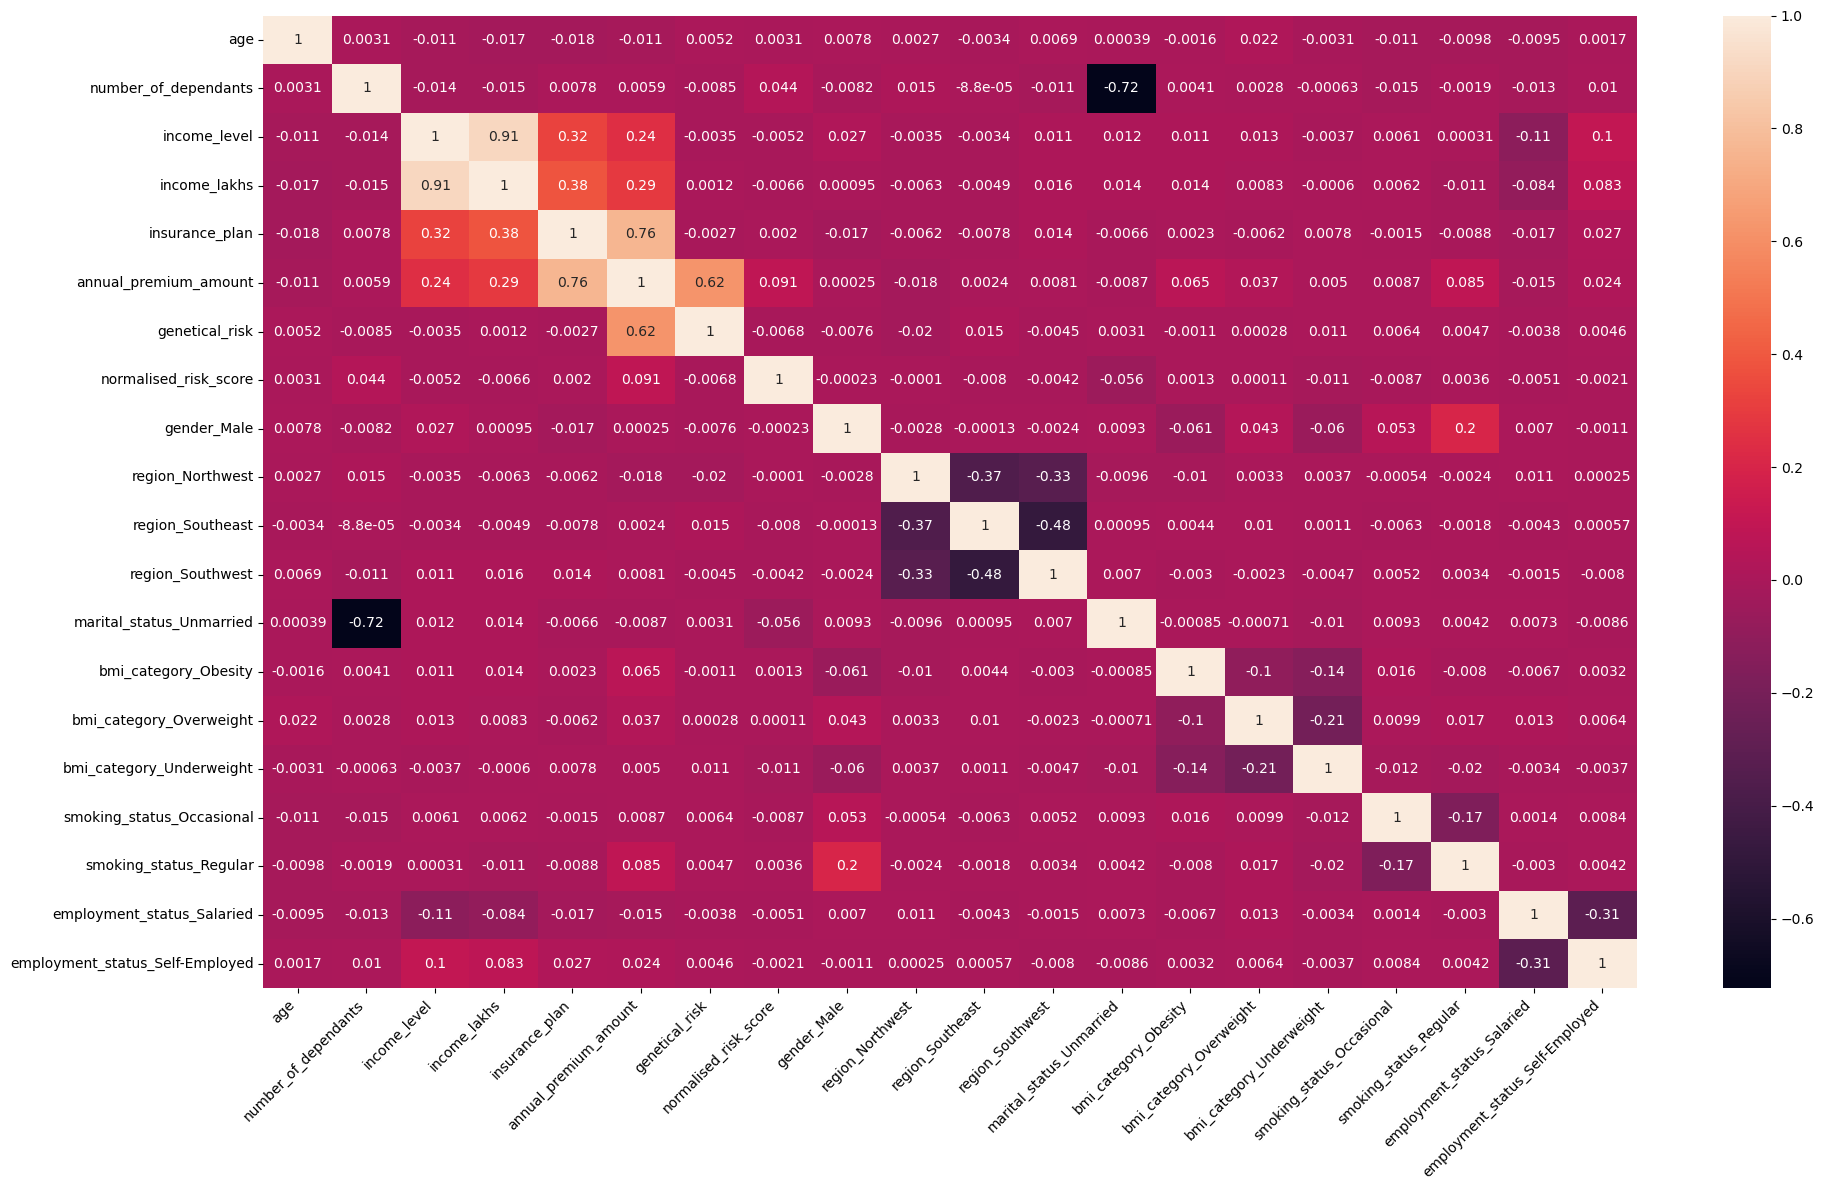

In [37]:
cm=df4.corr()

plt.figure(figsize=(20,12))
sns.heatmap(cm,annot=True)
plt.xticks(rotation=45,ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Scaling Numerical Columns

In [38]:
X=df4.drop("annual_premium_amount",axis=1)
y=df4["annual_premium_amount"]

cols_to_scale=["age","number_of_dependants","income_lakhs","income_level","insurance_plan",'genetical_risk']
scaler=MinMaxScaler()

X[cols_to_scale]=scaler.fit_transform(X[cols_to_scale])
X.head()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,genetical_risk,normalised_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,0.000000,0.000000,1.000000,0.989899,0.5,0.8,0.428571,1,0,0,0,1,0,1,0,0,1,0,1
1,0.571429,0.000000,0.000000,0.020202,0.5,0.6,0.000000,0,1,0,0,1,0,0,1,0,0,0,0
2,0.428571,0.000000,1.000000,0.969697,0.5,0.8,0.000000,0,0,1,0,1,0,0,0,0,1,1,0
3,1.000000,0.000000,0.333333,0.141414,0.0,0.4,0.000000,1,0,1,0,1,0,0,0,0,0,0,0
4,0.285714,0.666667,0.333333,0.131313,0.0,0.2,0.000000,1,0,1,0,1,0,1,0,0,0,0,0


### Feature Selection using VIF

VIF (Variance Inflation Factor) is used to detect multicollinearity.

Even within this segment, feature relationships may differ, 
so VIF is applied again to ensure model stability.

In [39]:
def calculate_vif(data):
    vif_df=pd.DataFrame()
    vif_df["Columns"]=data.columns
    vif_df["VIF"]=[variance_inflation_factor(data.values,i) for i in range(data.shape[1])]
    return vif_df

In [40]:
calculate_vif(X)

,Columns,VIF
0,age,3.154599
1,number_of_dependants,1.930428
2,income_level,11.928708
3,income_lakhs,11.876413
4,insurance_plan,1.592966
5,genetical_risk,2.981159
6,normalised_risk_score,1.154501
7,gender_Male,2.311831
8,region_Northwest,2.154355
9,region_Southeast,2.990493


In [41]:
calculate_vif(X.drop("income_level",axis=1))

,Columns,VIF
0,age,3.153255
1,number_of_dependants,1.927788
2,income_lakhs,2.294155
3,insurance_plan,1.587868
4,genetical_risk,2.981158
5,normalised_risk_score,1.154453
6,gender_Male,2.301658
7,region_Northwest,2.153423
8,region_Southeast,2.989301
9,region_Southwest,2.743932


Now VIF is less than 10 for all columns

In [42]:
X_reduced=X.drop("income_level",axis=1)


<h2 align="center"> Model Training</h2>

Models are retrained using the updated dataset with the additional feature.

The goal is to evaluate whether performance improves compared to previous models.

In [43]:
X_train,x_test,y_train,y_test=train_test_split(X_reduced,y,test_size=0.3,random_state=10)

In [44]:
X_train.shape

(14060, 18)

In [45]:
x_test.shape

(6026, 18)

### Linear Regression

In [46]:
model_lr=LinearRegression()
model_lr.fit(X_train,y_train)
train_score=model_lr.score(X_train,y_train)
test_score=model_lr.score(x_test,y_test)
train_score,test_score

(0.988297900194864, 0.9887263253056615)

In [47]:
np.set_printoptions(suppress=True, precision=6)
model_lr.coef_

array([  -7.229032,   19.536182,   -1.264528, 7001.125261, 4996.988728,
       1109.148365,    8.177988,    1.677353,   -3.275327,    6.317095,
         16.068972,  812.844929,  400.375598,  107.529819,  205.069661,
        610.98328 ,    0.038784,   -5.242018])

In [48]:
feature_importances=model_lr.coef_

In [49]:
coef_df=pd.DataFrame(feature_importances,index=x_test.columns,columns=["Coefficients"])
coef_df=coef_df.sort_values(by="Coefficients",ascending=True)
coef_df

,Coefficients
age,-7.229032
employment_status_Self-Employed,-5.242018
region_Southeast,-3.275327
income_lakhs,-1.264528
employment_status_Salaried,0.038784
region_Northwest,1.677353
region_Southwest,6.317095
gender_Male,8.177988
marital_status_Unmarried,16.068972
number_of_dependants,19.536182


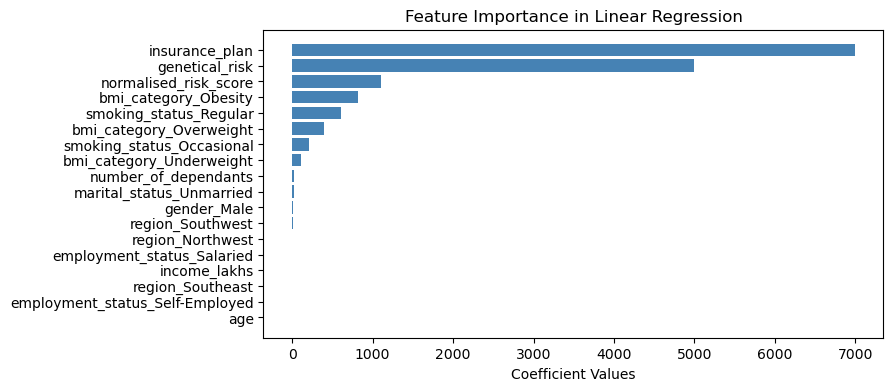

In [50]:
plt.figure(figsize=(8,4))
plt.barh(coef_df.index,coef_df["Coefficients"],color="steelblue")
plt.xlabel("Coefficient Values")
plt.title("Feature Importance in Linear Regression")
plt.show()

From the above feature distribution what matters the most for premium prediction for younger age are insurance_pan, genetical_risk and normalised_risk_score.

### XGBoost Regressor

In [51]:
model_xgb=XGBRegressor()
model_xgb.fit(X_train,y_train)
model_xgb.score(x_test,y_test)

0.987729549407959

with xgboost we got accuracy of 98%

### Random Search CV

In [52]:
model_xgb=XGBRegressor()

param_grid={
    'n_estimators':[20,40,50],
    'learning_rate':[0.01,0.1,0.2],
    'max_depth':[3,4,5]
}

random_search=RandomizedSearchCV(model_xgb,param_grid,n_iter=10,cv=3,scoring='r2',random_state=42,n_jobs=-1)
random_search.fit(X_train,y_train)
random_search.best_score_

0.9879226088523865

In [53]:
random_search.best_params_

{'n_estimators': 50, 'max_depth': 5, 'learning_rate': 0.1}

<h2> Model Evaluation</h2>

| Model                |R2(Without Genetic Risk)|R2(With Genetic Risk)|
|:---------------------|:----: |:---:|
|Linear               |0.60|0.99|
|XGBoost              |0.56|0.99|
|XGBoost Random Search |0.60|0.99|

### Insight

- Introduction of the genetic risk feature resulted in increase in model performance
- This indicates that the new feature does add meaningful predictive information
- Model performance is sensitive to feature quality rather than model complexity

<h1 align="center"> Error Analysis</h1>

In [54]:
best_model = model_lr

In [55]:
y_pred=best_model.predict(x_test)

residuals=y_pred-y_test
residuals_pct=residuals*100/y_test

results_df=pd.DataFrame({
    'actual':y_test,
    'predicted':y_pred,
    'diff':residuals,
    'diff_pct':residuals_pct
})

results_df.head()

,actual,predicted,diff,diff_pct
12774,6238,6121.456891,-116.543109,-1.868277
14758,9462,9601.797510,139.797510,1.477463
13205,5152,5611.056493,459.056493,8.910258
14278,6988,7423.486322,435.486322,6.231916
19351,4917,5112.056543,195.056543,3.966983


<Axes: xlabel='diff_pct', ylabel='Count'>

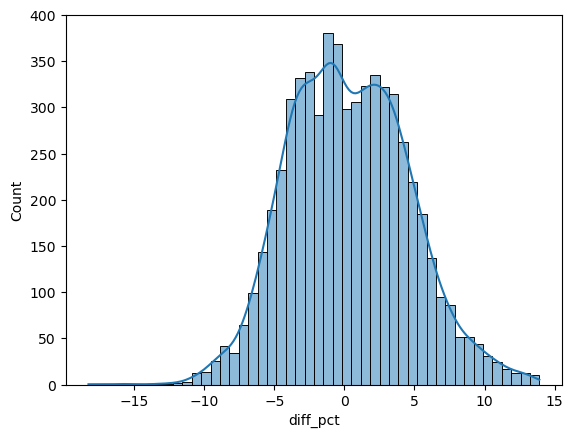

In [56]:
sns.histplot(results_df["diff_pct"],kde=True)

In [57]:
extreme_error_threshold=10
extreme_results_df=results_df[np.abs(results_df["diff_pct"])>extreme_error_threshold]
extreme_results_df.shape

(129, 4)

In [58]:
(extreme_results_df.shape[0]*100)/results_df.shape[0]

2.140723531364089

We now have only 2% extreme errors.

### Impact of Genetic Risk Feature

- Extreme error rate reduced significantly from 73% to 2% after introducing the genetic risk feature
- This demonstrates that the model’s previous limitations were primarily due to missing critical predictive information
- The genetic risk feature captures underlying health-related variability that was not represented in the original dataset
- Model performance improvement is driven more by feature quality than model complexity

### Key Observation

The dramatic reduction in prediction errors highlights the importance of domain-relevant features in healthcare modeling.

This confirms that:
- Feature engineering and data quality have a greater impact than model selection
- Incorporating meaningful health indicators significantly improves predictive performance

## Export the Model

In [61]:
dump(best_model,"C:/Users/elzab/Documents/Job/Data Science Learn/project_Healthcare Premium/ML_Project_Premium_Prediction/Artefacts/model_young.joblib")

['C:/Users/elzab/Documents/Job/Data Science Learn/project_Healthcare Premium/ML_Project_Premium_Prediction/Artefacts/model_young.joblib']

In [62]:
scaler_with_cols={
    'scaler':scaler,
    'cols_to_scale':cols_to_scale
}
dump(scaler_with_cols,"C:/Users/elzab/Documents/Job/Data Science Learn/project_Healthcare Premium/ML_Project_Premium_Prediction/Artefacts/scaler_young.joblib")

['C:/Users/elzab/Documents/Job/Data Science Learn/project_Healthcare Premium/ML_Project_Premium_Prediction/Artefacts/scaler_young.joblib']